In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

project_path = "/content/drive/MyDrive/arabic_sentiment_bert"

folders = [
    f"{project_path}/data/raw",
    f"{project_path}/data/processed",
    f"{project_path}/src",
    f"{project_path}/models",
    f"{project_path}/results",
    f"{project_path}/notebooks"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created successfully")

Project structure created successfully


In [4]:
!pip install transformers
!pip install torch
!pip install datasets
!pip install arabert
!pip install pandas
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 16.7 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=04db8a795a20aa5869b46bb3e248741ffc44ef5f2ec735b9d7be4e47938be4a5
  Stored in directory: /root/.cache/pip/wheels/bb/f1/26/f9002669ef6ad80a3c9f1b22880b35d9b4c6650011acee0523
Successfully built emoji


In [5]:
from datasets import load_dataset

dataset = load_dataset("labr")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/3.83M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/919k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11760 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2935 [00:00<?, ? examples/s]

In [6]:
import pandas as pd

train_df = dataset["train"].to_pandas()

train_df = train_df[["text", "label"]]

train_df.to_csv("reviews.csv", index=False, encoding="utf-8")

print("Dataset saved")

Dataset saved


In [7]:
import shutil

shutil.move(
    "reviews.csv",
    "/content/drive/MyDrive/arabic_sentiment_bert/data/raw/reviews.csv"
)

'/content/drive/MyDrive/arabic_sentiment_bert/data/raw/reviews.csv'

In [8]:
data_path ="/content/drive/MyDrive/arabic_sentiment_bert/data/raw/reviews.csv"

df = pd.read_csv(data_path)

df.head()

,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,0
1,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,0
3,خيالية جدًا . ماحبيتها الصراحة,0
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",0


In [9]:
df["label"] = df["label"].apply(lambda x: 1 if x > 2 else 0)

In [10]:
import re

def normalize_arabic(text):

    text = re.sub("[إأٱآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)

    text = re.sub("[^ا-ي ]", "", text)

    return text

In [11]:
df["text"] = df["text"].apply(normalize_arabic)

In [12]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(

    df["text"].tolist(),
    df["label"].tolist(),

    test_size=0.2,
    random_state=42
)

In [13]:
from transformers import AutoTokenizer

model_name = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [14]:
train_encodings = tokenizer(

    train_texts,

    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(

    test_texts,

    truncation=True,
    padding=True,
    max_length=128
)

In [15]:
import torch

class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [16]:
train_dataset = ReviewDataset(train_encodings, train_labels)

test_dataset = ReviewDataset(test_encodings, test_labels)

In [17]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(

    model_name,

    num_labels=2
)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [18]:
from transformers import Trainer
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="/content/drive/MyDrive/arabic_sentiment_bert/results",

    num_train_epochs=3,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,


    logging_dir=project_path + "/logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [19]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [20]:
trainer.train()

Step,Training Loss
500,0.532474
1000,0.380763
1500,0.256516


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1764, training_loss=0.3633402567061167, metrics={'train_runtime': 737.0911, 'train_samples_per_second': 38.291, 'train_steps_per_second': 2.393, 'total_flos': 1856511606620160.0, 'train_loss': 0.3633402567061167, 'epoch': 3.0})

In [22]:
import numpy as np
from sklearn.metrics import classification_report

predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1429
           1       0.74      0.76      0.75       923

    accuracy                           0.80      2352
   macro avg       0.79      0.79      0.79      2352
weighted avg       0.80      0.80      0.80      2352



In [35]:
import os

os.listdir("/content/drive/MyDrive/arabic_sentiment_bert/models/arabic_sentiment_bert/models")

['sentiment_model']

In [36]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer

model_path = "/content/drive/MyDrive/arabic_sentiment_bert/models/arabic_sentiment_bert/models/sentiment_model"

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    local_files_only=True
)

tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [37]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

def predict(text):

    inputs = tokenizer(text, return_tensors="pt")

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)

    pred = torch.argmax(outputs.logits).item()

    if pred == 1:
        return "Positive"
    else:
        return "Negative"

In [38]:
predict("المطعم رائع والطعام لذيذ")

'Positive'

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [40]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

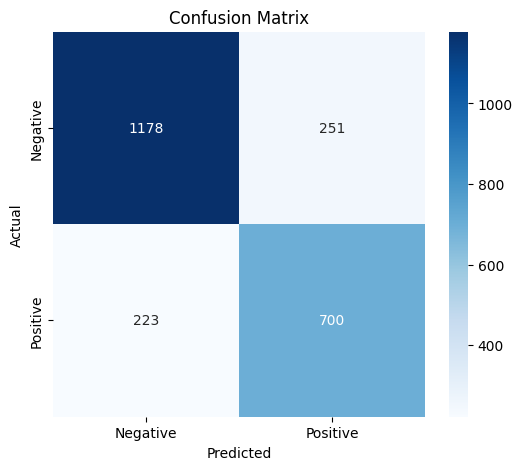

In [41]:
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [42]:
log_history = trainer.state.log_history

In [43]:
train_loss = []
eval_loss = []
steps = []

for log in log_history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

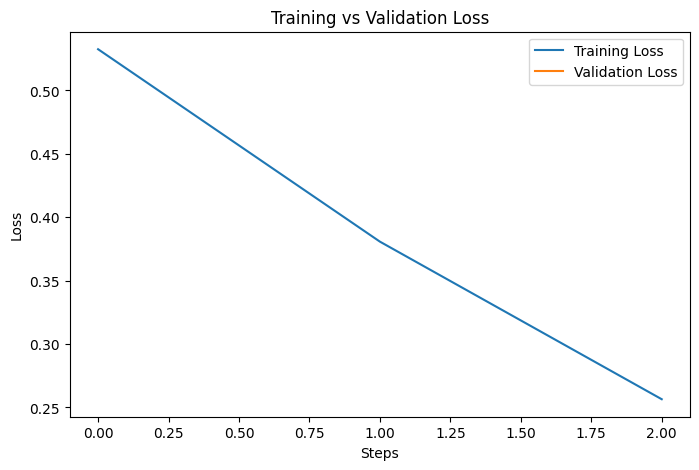

In [44]:
plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Training Loss")
plt.plot(eval_loss,label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

========== BERT RESULTS ==========
BERT Accuracy: 0.798469387755102
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1429
           1       0.74      0.76      0.75       923

    accuracy                           0.80      2352
   macro avg       0.79      0.79      0.79      2352
weighted avg       0.80      0.80      0.80      2352


========== SVM RESULTS ==========
SVM Accuracy: 0.7270408163265306
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1429
           1       0.66      0.63      0.65       923

    accuracy                           0.73      2352
   macro avg       0.71      0.71      0.71      2352
weighted avg       0.73      0.73      0.73      2352



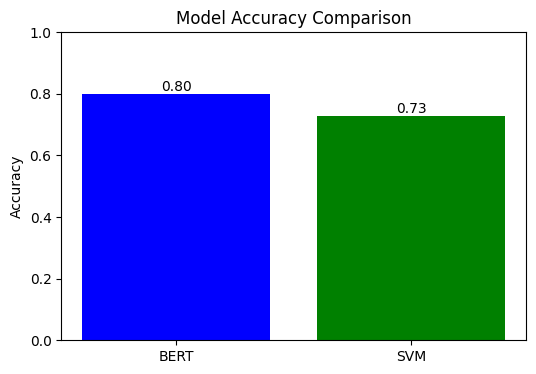


========== FINAL COMPARISON ==========
BERT Accuracy : 0.798
SVM Accuracy  : 0.727
BERT performs better than SVM


In [45]:
# ================================
# مقارنة BERT مع SVM
# ================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report


# =====================================
# 1️⃣ حساب نتائج BERT
# =====================================

bert_predictions = trainer.predict(test_dataset)

bert_preds = np.argmax(bert_predictions.predictions, axis=1)

bert_accuracy = accuracy_score(test_labels, bert_preds)

print("========== BERT RESULTS ==========")
print("BERT Accuracy:", bert_accuracy)
print(classification_report(test_labels, bert_preds))


# =====================================
# 2️⃣ تجهيز البيانات لنموذج SVM
# =====================================

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)


# =====================================
# 3️⃣ تدريب نموذج SVM
# =====================================

svm_model = LinearSVC()

svm_model.fit(X_train, train_labels)


# =====================================
# 4️⃣ التنبؤ باستخدام SVM
# =====================================

svm_preds = svm_model.predict(X_test)

svm_accuracy = accuracy_score(test_labels, svm_preds)

print("\n========== SVM RESULTS ==========")
print("SVM Accuracy:", svm_accuracy)
print(classification_report(test_labels, svm_preds))


# =====================================
# 5️⃣ رسم مقارنة النماذج
# =====================================

models = ["BERT", "SVM"]
scores = [bert_accuracy, svm_accuracy]

plt.figure(figsize=(6,4))

plt.bar(models, scores, color=["blue","green"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0,1)

plt.show()


# =====================================
# 6️⃣ طباعة المقارنة النهائية
# =====================================

print("\n========== FINAL COMPARISON ==========")

print(f"BERT Accuracy : {bert_accuracy:.3f}")
print(f"SVM Accuracy  : {svm_accuracy:.3f}")

if bert_accuracy > svm_accuracy:
    print("BERT performs better than SVM")
else:
    print("SVM performs better than BERT")

========== BERT RESULTS ==========
BERT Accuracy: 0.798469387755102
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1429
           1       0.74      0.76      0.75       923

    accuracy                           0.80      2352
   macro avg       0.79      0.79      0.79      2352
weighted avg       0.80      0.80      0.80      2352



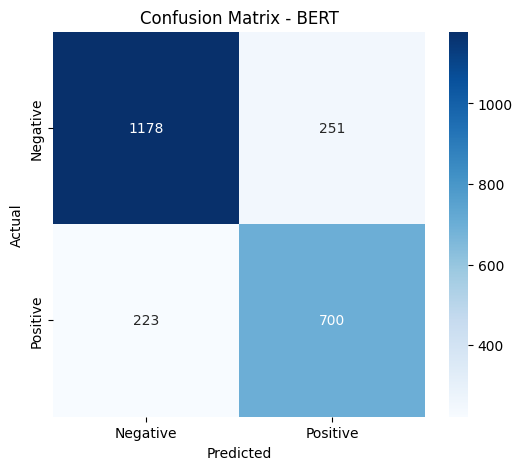

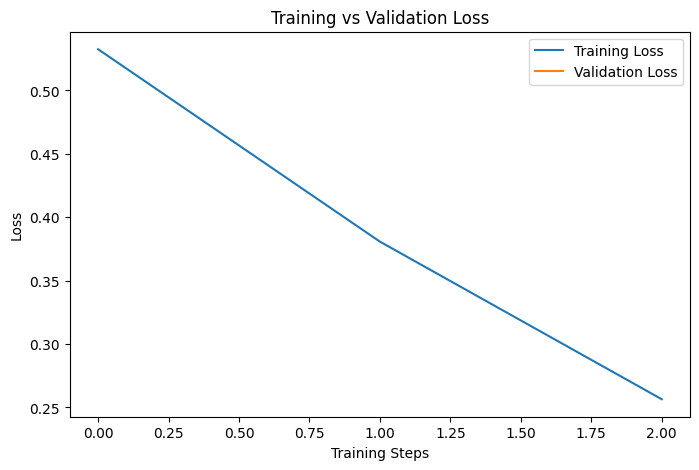


========== SVM RESULTS ==========
SVM Accuracy: 0.7270408163265306
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1429
           1       0.66      0.63      0.65       923

    accuracy                           0.73      2352
   macro avg       0.71      0.71      0.71      2352
weighted avg       0.73      0.73      0.73      2352



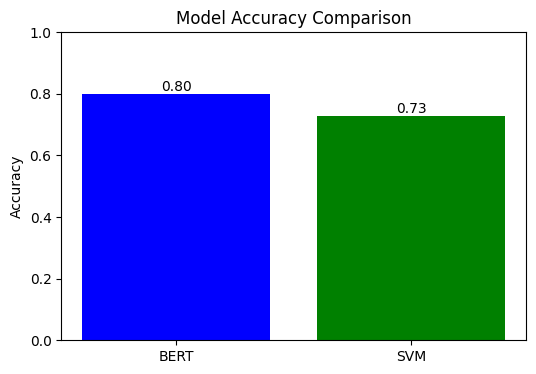


========== FINAL COMPARISON ==========
BERT Accuracy : 0.798
SVM Accuracy  : 0.727
BERT performs better than SVM

All graphs saved in results folder


In [46]:

# Final Evaluation: Confusion Matrix + Graphs + Model Comparison


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC


# مسار المشروع
project_path = "/content/drive/MyDrive/arabic_sentiment_bert/results"



# 1 حساب نتائج BERT

bert_predictions = trainer.predict(test_dataset)

bert_preds = np.argmax(bert_predictions.predictions, axis=1)

bert_accuracy = accuracy_score(test_labels, bert_preds)

print("========== BERT RESULTS ==========")
print("BERT Accuracy:", bert_accuracy)
print(classification_report(test_labels, bert_preds))


#
# 2 Confusion Matrix


cm = confusion_matrix(test_labels, bert_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT")

plt.savefig(project_path + "/confusion_matrix.png")

plt.show()


#
# 3 Accuracy Graph
#

log_history = trainer.state.log_history

train_loss = []
eval_loss = []

for log in log_history:
    if "loss" in log:
        train_loss.append(log["loss"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Training Loss")
plt.plot(eval_loss,label="Validation Loss")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.savefig(project_path + "/training_graph.png")

plt.show()



# 4 تدريب نموذج SVM


vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

svm_model = LinearSVC()

svm_model.fit(X_train, train_labels)

svm_preds = svm_model.predict(X_test)

svm_accuracy = accuracy_score(test_labels, svm_preds)

print("\n========== SVM RESULTS ==========")
print("SVM Accuracy:", svm_accuracy)
print(classification_report(test_labels, svm_preds))


# 5 رسم مقارنة النماذج


models = ["BERT", "SVM"]
scores = [bert_accuracy, svm_accuracy]

plt.figure(figsize=(6,4))

plt.bar(models, scores, color=["blue","green"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0,1)

plt.savefig(project_path + "/model_comparison.png")

plt.show()



# 6 طباعة النتيجة النهائية


print("\n========== FINAL COMPARISON ==========")

print(f"BERT Accuracy : {bert_accuracy:.3f}")
print(f"SVM Accuracy  : {svm_accuracy:.3f}")

if bert_accuracy > svm_accuracy:
    print("BERT performs better than SVM")
else:
    print("SVM performs better than BERT")


print("\nAll graphs saved in results folder")